<div class="alert alert-block alert-info" style="border-left: 6px solid #1f77b4; background-color: #e8f1fb; padding: 10px 14px;">

**Komentar ocenjevalca (ni del oddanega poročila)**

Projekt je zgled dobro izdelanega poročila: problem je ena zaokrožena celota, vsako poglavje uporabi rezultat prejšnjega, izbira metod je utemeljena in vsak rezultat je preverjen po neodvisni poti. 

Kaj bi bilo mogoče še dodati ali izboljšati:

* Formalnih testov kode (npr. `pytest`) in uporabniškega vmesnika ni; kreativni dodatek je omejen na animacijo padca.
* Meritve trenja in kota med padcem so sintetične (generirane iz istega modela z dodanim šumom); z realnimi meritvami bi bila ocena koeficienta trenja in primerjava poteka padca z modelom bistveno prepričljivejši.
* Negotovost koeficienta trenja je ocenjena, ni pa prenesena na ključna rezultata (kritična lega osebe in kritični kot); pri glajenem zlepku je parameter glajenja *s* določen iz ocene šuma, njegov vpliv na odvode pa ni preverjen.

</div>

Avtor: **Janez Novak, 23201111**

Datum: **1. oktober 2026**

*Potrjujem, da sem avtor projektne naloge in da sem vso vsebino pripravil sam. V primeru, da se ugotovi plagiatorstvo se zavedam, da ne bom izpolnjeval pogojev za pristop k izpitu.*

---

# Definicija naloge

## Opis problema

Enakomerna lestev dolžine $L = 4$ m in mase $m = 12$ kg je prislonjena na **gladko** navpično steno pod kotom $\theta$ (merjen od tal). Na tleh jo drži trenje s koeficientom $\mu$. Po lestvi pleza oseba mase $m_o = 80$ kg do razdalje $x$ od spodnjega konca. Zanimata nas dve inženirski vprašanji:

1. **Do kod** lahko oseba varno spleza pri danem kotu $\theta$ in koeficientu trenja $\mu$, oziroma pri katerem kotu je lestev varna po celotni dolžini?
2. Če lestev (brez osebe) stoji na gladkih tleh (npr. mokre ploščice) in zdrsne, **kako poteka padec** in kdaj se zgornji konec **odlepi od stene**?

Prvo vprašanje je naloga iz statike, drugo iz dinamike togega telesa; obe sta obravnavani v učbenikih [1, 2], od koder so vzete tudi oznake.

<img src="skica.png" width=480>

## Model, predpostavke in podatki

*Statika.* Na lestev delujejo teža lestve $m g$ v težišču, teža osebe $m_o g$ na razdalji $x$, na tleh normalna sila $N_A$ in sila trenja $F_A$ (proti steni), na gladki steni pa le normalna sila $N_B$. Ravnotežne enačbe so linearne v neznankah $F_A$, $N_A$ in $N_B$; lestev zdrsne, ko je

$$ F_A > \mu N_A. $$

*Dinamika padca.* Lestev brez osebe izpustimo iz mirovanja pri kotu $\theta_0$. Dokler se dotika tal in stene, ima eno prostostno stopnjo ($\theta$). Zgornji konec se odlepi od stene, ko sila stene pade na nič, $N_B = 0$; od tam naprej model ne velja.

Predpostavke: lestev je togo telo z enakomerno porazdeljeno maso (vztrajnostni moment okoli težišča $m L^2/12$), oseba je točkasta masa; stena je gladka, pri padcu so gladka tudi tla (razširitev s trenjem je v poglavju o diferencialnih enačbah); trenje na tleh je Coulombovo s konstantnim $\mu$; gibanje je ravninsko, zračni upor zanemarimo.

| Količina | Vrednost | Vir |
|---|---|---|
| $L$, $m$ | 4 m, 12 kg | tipična dvodelna aluminijasta lestev |
| $m_o$ | 80 kg | izbrano |
| $\mu$ | ocena 0,3; natančneje iz meritev v poglavju o aproksimaciji | tipična vrednost za gumo na suhem betonu |
| $\theta$ pri plezanju | 60° | izbrano (lestev, postavljena preveč položno) |
| $\theta_0$ pri padcu | 75° | pravilo 4 : 1 za postavitev lestve [3] |
| $g$ | 9,81 m/s$^2$ | |

Realnih meritev nimamo, zato so "meritve" v datotekah `meritve_trenje.csv` (sila vleka pri sedmih obremenitvah, šum 4 N) in `meritve_padec.csv` (kot lestve iz videa s 30 sličicami na sekundo, šum 0,5°) **sintetične**: generirane so iz istega modela z dodanim normalno porazdeljenim šumom (skripta `pripravi_meritve.py`). Na to omejitev opozorimo, kjer bi lahko vplivala na sklepe.

## Datoteke in zagon

* `lestev.py` – lastni modul z numeričnimi funkcijami (uvožen spodaj),
* `meritve_trenje.csv`, `meritve_padec.csv`, `pripravi_meritve.py` – meritve in skripta za njihovo pripravo,
* `narisi_skico.py`, `skica.png` – skica problema,
* `requirements.txt` – potrebni paketi; namestitev: `pip install -r requirements.txt`.

Najprej uvozimo knjižnice in lastni modul ter določimo podatke naloge.

In [1]:
import numpy as np
from scipy.linalg import lu_factor, lu_solve
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.interpolate import UnivariateSpline
from scipy.optimize import root_scalar, curve_fit
from scipy.integrate import quad, trapezoid, solve_ivp
import sympy as sym
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
from IPython.display import display, HTML

import lestev as le

In [2]:
L = 4.0                       # dolžina lestve [m]
m = 12.0                      # masa lestve [kg]
m_o = 80.0                    # masa osebe [kg]
g = 9.81                      # težni pospešek [m/s^2]
mu_ocena = 0.3                # ocena koeficienta trenja iz literature [-]
kot_osebe = np.radians(60.0)  # kot lestve pri plezanju osebe [rad]
theta0 = np.radians(75.0)     # začetni kot lestve pri padcu [rad]

---

# Simbolno reševanje

## Ravnotežje lestve z osebo

Ravnotežne enačbe (vsota sil v $x$ in $y$ ter momentov okoli točke $A$, oznake s skice) so

$$ F_A - N_B = 0, \qquad N_A - (m + m_o)\,g = 0, \qquad N_B\,L\sin\theta - m g\,\frac{L}{2}\cos\theta - m_o g\,x\cos\theta = 0. $$

Rešimo jih za reakcije $F_A$, $N_A$ in $N_B$. Iz pogoja zdrsa $F_A = \mu N_A$ nato dobimo **kritično lego osebe** $x_{kr}$ in, za lestev brez osebe, **kritični kot** $\theta_{kr}$. Simbolni izrazi so v nadaljevanju referenca za preverjanje numeričnih rezultatov.

**Izbira metode.** Sistem je linearen v neznankah, zato ga rešimo s `sympy.solve`; s tem se izognemo napakam pri ročni izpeljavi. Simbolna rešitev sama ne zadošča za inženirsko uporabo (v enačbah nastopa $\mu$, ki ga moramo izmeriti), zato jo z `lambdify` pretvorimo v numerične funkcije.

In [3]:
theta, x_s, L_s, m_s, mo_s, g_s, mu_s = sym.symbols(
    "theta x L m m_o g mu", positive=True)
F_A, N_A, N_B = sym.symbols("F_A N_A N_B")

vsota_x = sym.Eq(F_A - N_B, 0)
vsota_y = sym.Eq(N_A - (m_s + mo_s) * g_s, 0)
moment_A = sym.Eq(N_B * L_s * sym.sin(theta)
                  - m_s * g_s * L_s / 2 * sym.cos(theta)
                  - mo_s * g_s * x_s * sym.cos(theta), 0)

Rešitev sistema za reakcije.

In [4]:
reakcije_sim = sym.solve([vsota_x, vsota_y, moment_A], [F_A, N_A, N_B])
for sila in (F_A, N_A, N_B):
    display(sym.Eq(sila, sym.simplify(reakcije_sim[sila])))

Eq(F_A, g*(L*m + 2*m_o*x)/(2*L*tan(theta)))

Eq(N_A, g*(m + m_o))

Eq(N_B, g*(L*m + 2*m_o*x)/(2*L*tan(theta)))

Kritična lega osebe in kritični kot iz pogoja zdrsa $F_A = \mu N_A$.

In [5]:
pogoj_zdrsa = sym.Eq(reakcije_sim[F_A], mu_s * reakcije_sim[N_A])
x_kr_sim = sym.solve(pogoj_zdrsa, x_s)[0]
theta_kr_sim = sym.solve(pogoj_zdrsa.subs(mo_s, 0), theta)[0]
display(sym.Eq(sym.Symbol("x_kr"), sym.simplify(x_kr_sim)))
display(sym.Eq(sym.Symbol("theta_kr"), theta_kr_sim))

Eq(x_kr, L*(2*m*mu*tan(theta) - m + 2*m_o*mu*tan(theta))/(2*m_o))

Eq(theta_kr, atan(1/(2*mu)))

Pretvorba v numerični funkciji in prva ocena pri $\mu = 0{,}3$.

In [6]:
x_kr_fun = sym.lambdify((theta, mu_s, m_s, mo_s, L_s), x_kr_sim, "numpy")
theta_kr_fun = sym.lambdify(mu_s, theta_kr_sim, "numpy")
x_kr_ocena = x_kr_fun(kot_osebe, mu_ocena, m, m_o, L)
theta_kr_ocena = theta_kr_fun(mu_ocena)
print(f"x_kr pri 60° in mu = {mu_ocena}: {x_kr_ocena:.2f} m")
print(f"theta_kr pri mu = {mu_ocena}: {np.degrees(theta_kr_ocena):.1f}°")

x_kr pri 60° in mu = 0.3: 2.09 m
theta_kr pri mu = 0.3: 59.0°


Kritična lega v odvisnosti od kota (`sympy.plot`).

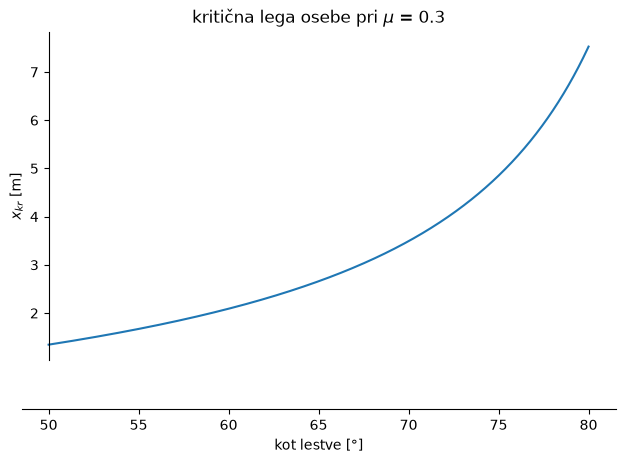

In [7]:
kot_stopinje = sym.symbols("theta_deg", positive=True)
podatki = {mu_s: mu_ocena, m_s: m, mo_s: m_o, L_s: L}
x_kr_izraz = x_kr_sim.subs(podatki).subs(theta, kot_stopinje * sym.pi / 180)
slika = sym.plot(x_kr_izraz, (kot_stopinje, 50, 80), axis_center=(50, 0),
                 xlabel="kot lestve [°]", ylabel="$x_{kr}$ [m]",
                 title=f"kritična lega osebe pri $\\mu$ = {mu_ocena}")

**Interpretacija.** Normalna sila na tleh je enaka skupni teži, sila stene pa raste linearno z lego osebe in s $\cot\theta$: bolj položna lestev potrebuje več trenja. Kritična lega je linearna v $\mu$ in $\tan\theta$; pri oceni $\mu = 0{,}3$ in $\theta = 60°$ bi oseba smela splezati le do približno 2,1 m. Kritični kot brez osebe

$$ \tan\theta_{kr} = \frac{1}{2\mu} $$

je pri $\mu = 0{,}3$ približno 59°, torej je lestev pri 60° tudi brez osebe tik nad mejo zdrsa. Slika kaže, kako hitro $x_{kr}$ narašča s $\tan\theta$: pri $\mu = 0{,}3$ doseže vrh lestve (4 m) pri približno 72°, pri 50° pa je le dober meter. Vrednosti so le ocena, ker $\mu$ še ni izmerjen.

## Enačba gibanja padca in pogoj odlepitve

Za lestev brez trenja je edina koordinata kot $\theta$; težišče je v $x_G = \frac{L}{2}\cos\theta$, $y_G = \frac{L}{2}\sin\theta$. Enačbo gibanja izpeljemo iz Lagrangeeve funkcije (kinetična energija translacije težišča in rotacije okoli njega), kotno hitrost $\omega(\theta)$ iz ohranitve energije, silo stene pa iz drugega Newtonovega zakona v vodoravni smeri,

$$ N_B = m\,\ddot{x}_G, $$

odlepitev nastopi pri $N_B = 0$.

**Izbira metode.** Lagrangeev pristop smo izbrali, ker pri eni prostostni stopnji reakcijske sile ne nastopajo; `sympy` opravi odvajanje po času. Enačba gibanja je nelinearna in nima zaprte rešitve $\theta(t)$, zato jo rešimo numerično v poglavju o diferencialnih enačbah.

In [8]:
t = sym.symbols("t", positive=True)
theta_t = sym.Function("theta")(t)
x_G = L_s / 2 * sym.cos(theta_t)
y_G = L_s / 2 * sym.sin(theta_t)
vztrajnostni_moment = m_s * L_s**2 / 12

kineticna = (m_s * (x_G.diff(t)**2 + y_G.diff(t)**2) / 2
             + vztrajnostni_moment * theta_t.diff(t)**2 / 2)
potencialna = m_s * g_s * y_G
lagrange = kineticna - potencialna
enacba_gibanja = (lagrange.diff(theta_t.diff(t)).diff(t)
                  - lagrange.diff(theta_t))
theta_dd = sym.solve(enacba_gibanja, theta_t.diff(t, 2))[0]
display(sym.Eq(theta_t.diff(t, 2), theta_dd))

Eq(Derivative(theta(t), (t, 2)), -3*g*cos(theta(t))/(2*L))

Kotna hitrost iz ohranitve energije, sila stene in pogoj odlepitve.

In [9]:
omega, theta0_s = sym.symbols("omega theta_0", positive=True)
energija = (kineticna + potencialna).subs(theta_t.diff(t), omega)
energija = energija.subs(theta_t, theta)
energija_zacetna = potencialna.subs(theta_t, theta0_s)
omega2_sim = sym.solve(sym.Eq(energija, energija_zacetna), omega**2)[0]
display(sym.Eq(omega**2, omega2_sim))

N_B_sim = m_s * x_G.diff(t, 2)
N_B_sim = N_B_sim.subs(theta_t.diff(t, 2), theta_dd)
N_B_sim = N_B_sim.subs(theta_t.diff(t), omega).subs(theta_t, theta)
N_B_sim = sym.factor(N_B_sim.subs(omega**2, omega2_sim))
display(sym.Eq(N_B, N_B_sim))
sin_odlepitve = sym.solve(N_B_sim, sym.sin(theta))[0]
display(sym.Eq(sym.sin(sym.Symbol("theta_od")), sin_odlepitve))

Eq(omega**2, 3*g*(-sin(theta) + sin(theta_0))/L)

Eq(N_B, 3*g*m*(3*sin(theta) - 2*sin(theta_0))*cos(theta)/4)

Eq(sin(theta_od), 2*sin(theta_0)/3)

Numerični funkciji in primerjava s funkcijami v modulu.

In [10]:
omega_fun = sym.lambdify((theta, theta0_s, L_s, g_s), sym.sqrt(omega2_sim))
N_B_fun = sym.lambdify((theta, theta0_s, m_s, g_s), N_B_sim, "numpy")

koti_test = np.radians([45.0, 55.0, 65.0, 74.0])
np.testing.assert_allclose(omega_fun(koti_test, theta0, L, g),
                           le.omega_energija(koti_test, theta0, L, g))
np.testing.assert_allclose(N_B_fun(koti_test, theta0, m, g),
                           le.sila_stene_energija(koti_test, theta0, m, g))

**Interpretacija.** Kotni pospešek

$$ \ddot\theta = -\frac{3g}{2L}\cos\theta $$

je največji pri položni lestvi in gre proti nič pri navpični, zato padec iz strme lege začne počasi. Sila stene

$$ N_B(\theta) = \frac{3}{4}\, m g \cos\theta\,\bigl(3\sin\theta - 2\sin\theta_0\bigr) $$

je na začetku pozitivna in pada do nič pri

$$ \sin\theta_{od} = \tfrac{2}{3}\sin\theta_0, $$

kar je znan rezultat iz dinamike togih teles; kot odlepitve je neodvisen od $m$, $L$ in $g$ in pri $\theta_0 = 75°$ znaša približno 40°. Kotna hitrost iz energije velja le do odlepitve, ker se po njej spremeni število prostostnih stopenj. Isti izrazi so zapisani tudi v modulu (`le.omega_energija`, `le.sila_stene_energija`); ujemanje smo zgoraj preverili z `np.testing.assert_allclose`.

---

# Sistemi linearnih enačb

## Reakcije vzdolž lestve

Ravnotežne enačbe zapišemo v matrični obliki

$$ \mathbf{A}(\theta)\,[F_A,\ N_A,\ N_B]^T = \mathbf{b}(x), $$

kjer je matrika odvisna le od kota, desna stran pa od lege osebe (funkciji `le.matrika_ravnotezja` in `le.desna_stran`). Zanima nas tabela reakcij za osebo na več položajih pri istem kotu.

**Izbira metode.** Ker je matrika za vse položaje ista, jo razcepimo enkrat (`scipy.linalg.lu_factor`) in za vsako desno stran rešimo le dva trikotna sistema (`lu_solve`). Pri sistemu $3 \times 3$ hitrost ni bistvena; argument je metodološki (pri velikih sistemih z mnogo desnimi stranmi je to $O(n^2)$ na desno stran namesto $O(n^3)$). Iterativne metode tu niso smiselne: sistem je majhen in ga direktna metoda reši točno. Rezultat pri enem položaju preverimo z `np.linalg.solve` in s simbolno rešitvijo.

In [11]:
A_sistem = le.matrika_ravnotezja(kot_osebe, L)
b_sistem = le.desna_stran(kot_osebe, 2.0, m, m_o, L, g)
razcep = lu_factor(A_sistem)
resitev_lu = lu_solve(razcep, b_sistem)

Kontrola z `np.linalg.solve` in s simbolno rešitvijo.

In [12]:
resitev_np = np.linalg.solve(A_sistem, b_sistem)
vrednosti = {theta: kot_osebe, x_s: 2.0, L_s: L, m_s: m, mo_s: m_o, g_s: g}
resitev_sim = [float(reakcije_sim[sila].subs(vrednosti))
               for sila in (F_A, N_A, N_B)]
np.testing.assert_allclose(resitev_lu, resitev_np, rtol=1e-12)
np.testing.assert_allclose(resitev_lu, resitev_sim, rtol=1e-12)
print(f"F_A = {resitev_lu[0]:.1f} N")
print(f"N_A = {resitev_lu[1]:.1f} N")
print(f"N_B = {resitev_lu[2]:.1f} N")

F_A = 260.5 N
N_A = 902.5 N
N_B = 260.5 N


Reakcije za devet položajev osebe z istim razcepom.

In [13]:
lege_osebe = np.linspace(0.0, L, 9)
reakcije = np.zeros((lege_osebe.size, 3))
for i, lega in enumerate(lege_osebe):
    b_lega = le.desna_stran(kot_osebe, lega, m, m_o, L, g)
    reakcije[i] = lu_solve(razcep, b_lega)

tabela_reakcij = pd.DataFrame(reakcije,
                              columns=["F_A [N]", "N_A [N]", "N_B [N]"])
tabela_reakcij.insert(0, "x [m]", lege_osebe)
tabela_reakcij["F_A / N_A"] = reakcije[:, 0] / reakcije[:, 1]
tabela_reakcij.round(3)

,x [m],F_A [N],N_A [N],N_B [N],F_A / N_A
0,0.0,33.983,902.52,33.983,0.038
1,0.5,90.621,902.52,90.621,0.100
2,1.0,147.259,902.52,147.259,0.163
3,1.5,203.897,902.52,203.897,0.226
4,2.0,260.535,902.52,260.535,0.289
5,2.5,317.173,902.52,317.173,0.351
6,3.0,373.811,902.52,373.811,0.414
7,3.5,430.449,902.52,430.449,0.477
8,4.0,487.087,902.52,487.087,0.540


Prikaz potrebnega koeficienta trenja vzdolž lestve.

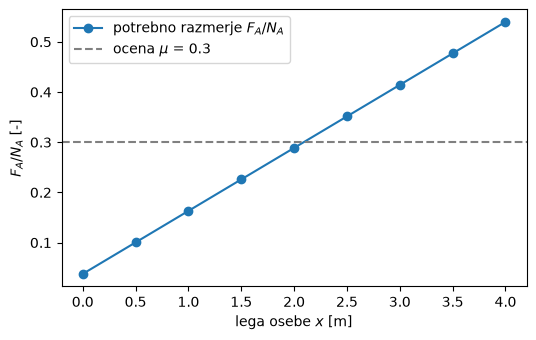

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(lege_osebe, tabela_reakcij["F_A / N_A"], "o-",
        label="potrebno razmerje $F_A / N_A$")
ax.axhline(mu_ocena, color="gray", ls="--",
           label=f"ocena $\\mu$ = {mu_ocena}")
ax.set_xlabel("lega osebe $x$ [m]")
ax.set_ylabel("$F_A / N_A$ [-]")
ax.legend()
plt.show()

**Interpretacija.** Vse tri poti dajo enak rezultat na relativno $10^{-12}$. Normalna sila na tleh (903 N) ni odvisna od lege osebe, sila stene in z njo potrebna sila trenja pa rasteta linearno s $x$: od 34 N brez osebe do 487 N z osebo na vrhu. Razmerje $F_A/N_A$ je potrebni koeficient trenja; pri 60° znaša na vrhu 0,54, kar nobena običajna podlaga ne zagotavlja. Presečišče z razpoložljivim $\mu$ je kritična lega, ki jo določimo v poglavju o iskanju ničel.

## Pogojenost sistema

Preden matriko uporabimo pri drugih kotih, preverimo njeno pogojenost $\mathrm{cond}(\mathbf{A})$, ki pove, kolikokrat se relativna napaka podatkov lahko ojača v rešitvi.

In [15]:
koti_cond = np.radians(np.array([1.0, 5.0, 30.0, 60.0, 89.0]))
for kot in koti_cond:
    pogojenost = np.linalg.cond(le.matrika_ravnotezja(kot, L))
    print(f"cond(A) pri {np.degrees(kot):4.0f}°: {pogojenost:6.2f}")

cond(A) pri    1°:  28.68
cond(A) pri    5°:   5.92
cond(A) pri   30°:   2.62
cond(A) pri   60°:   3.78
cond(A) pri   89°:   4.27


**Interpretacija.** Pri uporabnih kotih je pogojenost majhna (reda 3–5), pri $\theta \to 0$ pa narašča kot $1/\sin\theta$ in sistem postane singularen. Fizikalno: pri položni lestvi ima sila stene vse manjšo ročico $L\sin\theta$, pri $\theta = 0$ pa momenta teže ne more uravnotežiti, torej ravnotežje ne obstaja. Rahlo večja vrednost pri velikih kotih je posledica mešanja enot v matriki (element $L\sin\theta \approx 4$ m proti brezdimenzijskim enicam), ne numerični problem.

---

# Interpolacija / aproksimacija

## Koeficient trenja iz meritev

Nogo lestve smo obremenili z znano normalno silo $N$ in s silomerom "izmerili" silo $F$ za enakomerno vleko; sedem točk od 100 N do 700 N je v `meritve_trenje.csv` (sintetične).

**Izbira metode.** Coulombov zakon $F = \mu N$ je premica **skozi izhodišče** z enim parametrom, meritve pa so zašumljene, zato jih ne interpoliramo, ampak **aproksimiramo po metodi najmanjših kvadratov**: model z enim parametrom, $F(N) = \mu N$, prilagodimo meritvam s `scipy.optimize.curve_fit`, ki vrne tudi kovariančno matriko parametrov in s tem negotovost $\mu$. Ker je model linearen v parametru, je rezultat enak rešitvi normalnih enačb. Za primerjavo prilagodimo še splošno premico (`np.polyfit` stopnje 1, kot objekt `np.poly1d`); pri pravilnem modelu mora biti njen odsek v okviru šuma enak nič, sicer bi to kazalo na sistematično napako meritve.

Branje meritev iz datoteke.

In [16]:
meritve_trenja = pd.read_csv("meritve_trenje.csv")
N_mer = meritve_trenja["N [N]"].to_numpy()
F_mer = meritve_trenja["F [N]"].to_numpy()

Premica skozi izhodišče, splošna premica in negotovost $\mu$.

In [17]:
def coulomb(N, mu):
    """Coulombov zakon trenja: sila vleka pri normalni sili N [N]."""
    return mu * N


popt, pcov = curve_fit(coulomb, N_mer, F_mer)
mu = popt[0]
sigma_mu = np.sqrt(pcov[0, 0])
premica = np.poly1d(np.polyfit(N_mer, F_mer, 1))
naklon, odsek = premica.coeffs
ostanki = F_mer - coulomb(N_mer, mu)
odklon_ostankov = np.sqrt(ostanki @ ostanki / (N_mer.size - 1))

Izpis rezultatov.

In [18]:
print(f"mu (curve_fit, F = mu N) = {mu:.4f} ± {sigma_mu:.4f}")
print(f"polyfit: naklon = {naklon:.4f}, odsek = {odsek:.2f} N")
print(f"standardni odklon ostankov = {odklon_ostankov:.2f} N")

mu (curve_fit, F = mu N) = 0.3231 ± 0.0018
polyfit: naklon = 0.3247, odsek = -0.81 N
standardni odklon ostankov = 2.14 N


Prikaz meritev in obeh premic.

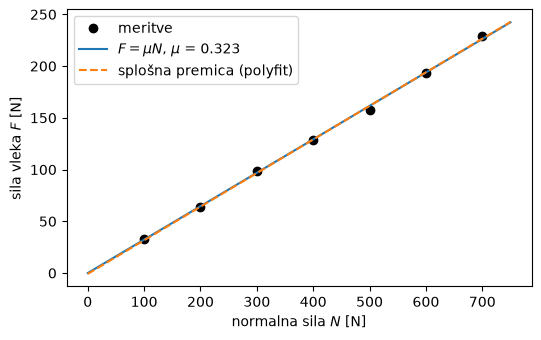

In [19]:
N_gosto = np.linspace(0.0, 750.0, 50)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(N_mer, F_mer, "ko", label="meritve")
ax.plot(N_gosto, coulomb(N_gosto, mu),
        label=f"$F = \\mu N$, $\\mu$ = {mu:.3f}")
ax.plot(N_gosto, premica(N_gosto), "--",
        label="splošna premica (polyfit)")
ax.set_xlabel("normalna sila $N$ [N]")
ax.set_ylabel("sila vleka $F$ [N]")
ax.legend()
plt.show()

**Interpretacija.** Izmerjeni koeficient trenja je $\mu = 0{,}323 \pm 0{,}002$, nekoliko več od začetne ocene. Odsek splošne premice ($-0{,}8$ N) je zanemarljiv proti raztrosu ostankov (2 N), naklon pa se od $\mu$ razlikuje za manj kot negotovost; model skozi izhodišče je upravičen in ima manj parametrov. Ker so meritve sintetične, ujemanje potrjuje predvsem doslednost postopka. V nadaljevanju uporabljamo $\mu = 0{,}323$.

## Kot lestve med padcem iz videa

Padec lestve (brez osebe, gladka tla, $\theta_0 = 75°$) smo "posneli" s 30 sličicami na sekundo in iz vsake odčitali kot; 30 točk do odlepitve je v `meritve_padec.csv` (sintetične, šum 0,5°). V poglavju o odvajanju bomo iz njih računali kotno hitrost in pospešek, zato potrebujemo $\theta(t)$ kot gladko funkcijo.

**Izbira metode.** Primerjamo **interpolacijski kubični zlepek** (`InterpolatedUnivariateSpline`), ki gre skozi vse točke, in **glajeni zlepek** (`UnivariateSpline`), ki je aproksimacija: išče najgladkejši zlepek, katerega vsota kvadratov odstopanj od točk ne preseže parametra $s$. Ker je $s$ zgornja meja te vsote, je naravna izbira

$$ s = n\,\sigma_\theta^2, \qquad n = 30,\ \sigma_\theta = 0{,}5° \ \text{(v radianih)}: $$

zlepek sme od meritev odstopati toliko, kolikor znaša ocenjeni šum, in nič več. Pri zašumljenih podatkih interpolacija sledi tudi šumu, kar se pri $\theta(t)$ komaj vidi, pri odvodih pa postane odločilno.

Branje kota iz videa.

In [20]:
meritve_padca = pd.read_csv("meritve_padec.csv")
t_mer = meritve_padca["t [s]"].to_numpy()
theta_mer = np.radians(meritve_padca["theta [deg]"].to_numpy())

Interpolacijski in glajeni zlepek ter njun odmik od meritev.

In [21]:
sum_kota = np.radians(0.5)                  # ocena šuma odčitka [rad]
parameter_s = t_mer.size * sum_kota**2      # dovoljena vsota kvadratov
zlepek_int = InterpolatedUnivariateSpline(t_mer, theta_mer)
zlepek_gl = UnivariateSpline(t_mer, theta_mer, s=parameter_s)
odmik_gl = np.degrees(theta_mer - zlepek_gl(t_mer))
print(f"število meritev: {t_mer.size}, korak {t_mer[1] - t_mer[0]:.4f} s")
print(f"RMS odmik glajenega zlepka od meritev: {np.std(odmik_gl):.2f}°")
print(f"število vozlišč glajenega zlepka: {zlepek_gl.get_knots().size}")

število meritev: 30, korak 0.0333 s
RMS odmik glajenega zlepka od meritev: 0.36°
število vozlišč glajenega zlepka: 2


Prikaz meritev in obeh zlepkov.

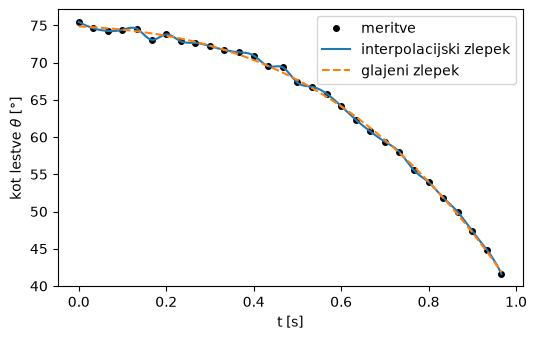

In [22]:
t_gosto_mer = np.linspace(t_mer[0], t_mer[-1], 300)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(t_mer, np.degrees(theta_mer), "ko", ms=4, label="meritve")
ax.plot(t_gosto_mer, np.degrees(zlepek_int(t_gosto_mer)),
        label="interpolacijski zlepek")
ax.plot(t_gosto_mer, np.degrees(zlepek_gl(t_gosto_mer)), "--",
        label="glajeni zlepek")
ax.set_xlabel("t [s]")
ax.set_ylabel("kot lestve $\\theta$ [°]")
ax.legend()
plt.show()

**Interpretacija.** Krivulji skoraj sovpadata; glajeni zlepek od meritev odstopa za 0,36° (RMS), kar je pod ocenjenim šumom 0,5°. Pri izbranem $s$ ima le dve vozlišči, torej je na celem intervalu en kubični polinom, ki potek $\theta(t)$ v tem kratkem času opiše v okviru šuma. Razlika med zlepkoma bo vidna pri odvajanju.

---

# Reševanje enačb (iskanje ničel)

## Kritična lega osebe

Iščemo lego $x_{kr}$, pri kateri je

$$ f(x) = F_A(x) - \mu N_A(x) = 0; $$

reakciji izračunamo iz linearnega sistema z razcepom iz prejšnjega poglavja, $\mu$ je izmerjen.

**Izbira metode.** Funkcija $f$ je zvezna in na $[0, L]$ zamenja predznak, zato je prva izbira **Brentova metoda** (`root_scalar`, `method='brentq'`): zagotovo konvergira in je superlinearna. Za primerjavo uporabimo **Newtonovo metodo** z odvodom iz simbolne rešitve, $f'(x) = m_o g/(L\tan\theta)$; konvergira kvadratično, a potrebuje odvod in dober začetni približek. Ker je $f$ linearna, Newtonova metoda konvergira v enem koraku, kar je dober test implementacije. Rezultat preverimo z analitičnim izrazom. Nato z `brentq` določimo še $x_{kr}$ za več kotov in kot, pri katerem je $x_{kr} = L$ (varna cela lestev).

In [23]:
def presezek_trenja(lega):
    """Potrebna minus razpoložljiva sila trenja pri legi osebe [N]."""
    b_lega = le.desna_stran(kot_osebe, lega, m, m_o, L, g)
    F_A_num, N_A_num, _ = lu_solve(razcep, b_lega)
    return F_A_num - mu * N_A_num


def odvod_presezka(lega):
    """Odvod f po legi osebe iz simbolne rešitve (konstanten) [N/m]."""
    return m_o * g / (L * np.tan(kot_osebe))

Iskanje ničle z Brentovo in Newtonovo metodo, kontrola z analitičnim izrazom.

In [24]:
brent = root_scalar(presezek_trenja, bracket=[0.0, L], method="brentq")
newton = root_scalar(presezek_trenja, x0=1.0, fprime=odvod_presezka,
                     method="newton")
x_kr_brent = brent.root
x_kr_analit = le.kriticna_lega(kot_osebe, mu, m, m_o, L)
np.testing.assert_allclose([x_kr_brent, newton.root], x_kr_analit, rtol=1e-8)

Izpis rezultatov.

In [25]:
print(f"f(0) = {presezek_trenja(0.0):.1f} N")
print(f"f(L) = {presezek_trenja(L):.1f} N")
print(f"brentq: x_kr = {x_kr_brent:.6f} m, iteracij: {brent.iterations}")
print(f"newton: x_kr = {newton.root:.6f} m, iteracij: {newton.iterations}")
print(f"analitično: x_kr = {x_kr_analit:.6f} m")

f(0) = -257.6 N
f(L) = 195.5 N
brentq: x_kr = 2.274164 m, iteracij: 3
newton: x_kr = 2.274164 m, iteracij: 2
analitično: x_kr = 2.274164 m


Funkcija $f$ za poljuben kot in za osebo na vrhu lestve.

In [26]:
def presezek_trenja_kot(lega, kot):
    """Potrebna minus razpoložljiva sila trenja pri legi in kotu [N]."""
    A_kot = le.matrika_ravnotezja(kot, L)
    b_kot = le.desna_stran(kot, lega, m, m_o, L, g)
    F_A_num, N_A_num, _ = np.linalg.solve(A_kot, b_kot)
    return F_A_num - mu * N_A_num


def presezek_na_vrhu(kot):
    """f pri osebi na vrhu lestve; ničla je kot za varno celo lestev [N]."""
    return presezek_trenja_kot(L, kot)

Kritična lega pri kotih od 58° do 70°.

In [27]:
koti_plezanja = np.radians(np.linspace(58.0, 70.0, 13))
x_kr_koti = np.zeros(koti_plezanja.size)
for i, kot in enumerate(koti_plezanja):
    x_kr_koti[i] = root_scalar(presezek_trenja_kot, args=(kot,),
                               bracket=[0.0, L], method="brentq").root
x_kr_koti_analit = le.kriticna_lega(koti_plezanja, mu, m, m_o, L)
razlika_koti = np.abs(x_kr_koti - x_kr_koti_analit)
print(f"največja razlika brentq - analitično: {razlika_koti.max():.1e} m")

največja razlika brentq - analitično: 8.9e-16 m


Kot, pri katerem je varna cela lestev.

In [28]:
interval_vrha = [np.radians(58.0), np.radians(80.0)]
kot_cele_lestve = root_scalar(presezek_na_vrhu, bracket=interval_vrha,
                              method="brentq").root
print(f"cela lestev je varna pri kotu nad {np.degrees(kot_cele_lestve):.1f}°")

cela lestev je varna pri kotu nad 70.9°


Prikaz kritične lege v odvisnosti od kota.

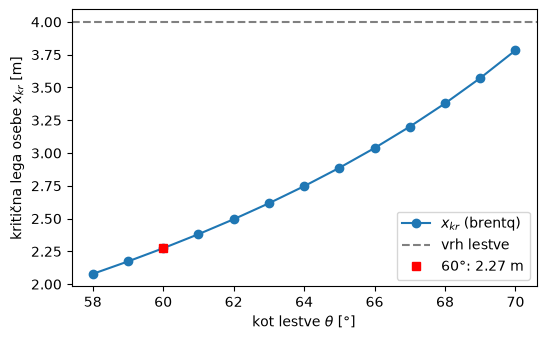

In [29]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(np.degrees(koti_plezanja), x_kr_koti, "o-", label="$x_{kr}$ (brentq)")
ax.axhline(L, color="gray", ls="--", label="vrh lestve")
ax.plot(60.0, x_kr_brent, "rs", label=f"60°: {x_kr_brent:.2f} m")
ax.set_xlabel("kot lestve $\\theta$ [°]")
ax.set_ylabel("kritična lega osebe $x_{kr}$ [m]")
ax.legend()
plt.show()

**Interpretacija.** Pri 60° in $\mu = 0{,}323$ lahko oseba varno spleza do $x_{kr} = 2{,}27$ m, le nekaj več kot do polovice lestve. Brentova metoda potrebuje tri iteracije, Newtonova zaradi linearnosti $f$ eno; obe se z analitičnim izrazom ujemata na zaokrožitveno napako. Kritična lega narašča s $\tan\theta$: pri 65° je 2,9 m, cela lestev pa je varna šele pri kotu nad 70,9°, kar numerično potrjuje pravilo 4 : 1 (75°) iz [3].

## Kritični kot brez osebe in kot odlepitve

Za lestev brez osebe iščemo kot, pri katerem je $f(\theta) = F_A(\theta) - \mu N_A(\theta) = 0$; funkcija je nelinearna v $\theta$ (vsebuje $\cot\theta$), zato uporabimo `brentq` na $[20°, 85°]$ in preverimo s $\tan\theta_{kr} = 1/(2\mu)$. Kot odlepitve pri padcu je ničla sile stene $N_B(\theta)$ iz simbolnega poglavja; $N_B$ je pri $\theta_0$ pozitivna, pri majhnih kotih negativna, zato spet uporabimo `brentq` in preverimo s $\sin\theta_{od} = \frac{2}{3}\sin\theta_0$.

In [30]:
def presezek_brez_osebe(kot):
    """Potrebna minus razpoložljiva sila trenja brez osebe [N]."""
    A_kot = le.matrika_ravnotezja(kot, L)
    b_kot = le.desna_stran(kot, 0.0, m, 0.0, L, g)
    F_A_num, N_A_num, _ = np.linalg.solve(A_kot, b_kot)
    return F_A_num - mu * N_A_num


def sila_stene_kot(kot):
    """Sila stene pri kotu lestve, kotna hitrost iz energije [N]."""
    return N_B_fun(kot, theta0, m, g)

Ničli obeh funkcij in kontrola z analitičnimi izrazi.

In [31]:
theta_kr_brent = root_scalar(presezek_brez_osebe, method="brentq",
                             bracket=[np.radians(20.0), np.radians(85.0)]).root
theta_kr_analit = le.kriticni_kot(mu)
theta_od_brent = root_scalar(sila_stene_kot, method="brentq",
                             bracket=[np.radians(10.0), theta0]).root
theta_od_analit = le.kot_odlepitve(theta0)
np.testing.assert_allclose([theta_kr_brent, theta_od_brent],
                           [theta_kr_analit, theta_od_analit], rtol=1e-8)

Izpis rezultatov.

In [32]:
print(f"theta_kr: brentq {np.degrees(theta_kr_brent):.4f}°, "
      f"analitično {np.degrees(theta_kr_analit):.4f}°")
print(f"theta_od: brentq {np.degrees(theta_od_brent):.4f}°, "
      f"analitično {np.degrees(theta_od_analit):.4f}°")
print(f"N_B na začetku padca: {sila_stene_kot(theta0):.1f} N")

theta_kr: brentq 57.1306°, analitično 57.1306°
theta_od: brentq 40.0870°, analitično 40.0870°
N_B na začetku padca: 22.1 N


**Interpretacija.** Brez osebe lestev pri izmerjenem $\mu$ zdrsne pod kotom 57,1°; kot 60° je le 3° nad mejo, kar pojasni, zakaj oseba sme splezati komaj do polovice. Pri padcu iz 75° se zgornji konec odlepi pri 40,1°, ko sila stene pade z 22 N na nič; od tam naprej lestev prosto pada in se vrti, kar presega ta model. Vse ničle se z analitičnimi izrazi ujemajo na $10^{-8}$ ali bolje.

---

# Integriranje / odvajanje

## Čas padca do odlepitve (numerično integriranje)

Kotno hitrost $\omega(\theta)$ poznamo iz energije, časa $\theta(t)$ pa ne. Čas do odlepitve dobimo iz $\mathrm{d}t = \mathrm{d}\theta/\omega$:

$$ t_{od} = \int_{\theta_{od}}^{\theta_0} \frac{\mathrm{d}\theta}{\omega(\theta)}, \qquad \omega(\theta) = \sqrt{\frac{3g}{L}\left(\sin\theta_0 - \sin\theta\right)}. $$

Integrand ima pri zgornji meji integrabilno **singularnost** ($\omega = 0$, obnaša se kot $1/\sqrt{\theta_0 - \theta}$).

**Izbira metode.** `scipy.integrate.quad` (adaptivna Gauss-Kronrodova kvadratura) integranda v krajiščih ne izvrednoti in intervale ob singularnosti zgošča, zato jo obvlada in vrne oceno napake. Za primerjavo uporabimo **trapezno pravilo** na enakomerni mreži: zgornje vozlišče, kjer je integrand neskončen, izpustimo; napaka je potem določena z izpuščenim intervalom in pada le kot $n^{-1/2}$, ne kot $n^{-2}$ pri gladkih integrandih. Trapezno pravilo bi delovalo šele po substituciji, ki singularnost odpravi (npr. $\theta = \theta_0 - u^2$).

In [33]:
theta_od = theta_od_brent
t_od_quad, napaka_quad = quad(le.integrand_casa, theta_od, theta0,
                              args=(theta0, L, g))
print(f"quad: t_od = {t_od_quad:.6f} s, ocena napake {napaka_quad:.1e} s")

quad: t_od = 0.988220 s, ocena napake 3.1e-10 s


Trapezno pravilo na vse gostejši mreži.

In [34]:
stevila_intervalov = np.array([10, 100, 1000, 10000])
for n in stevila_intervalov:
    mreza = np.linspace(theta_od, theta0, n + 1)[:-1]   # brez singularnosti
    integrand = le.integrand_casa(mreza, theta0, L, g)
    napaka_trapez = abs(trapezoid(integrand, mreza) - t_od_quad)
    print(f"trapez, n = {n:6d}: napaka {napaka_trapez:.4f} s")

trapez, n =     10: napaka 0.3442 s
trapez, n =    100: napaka 0.1107 s
trapez, n =   1000: napaka 0.0351 s
trapez, n =  10000: napaka 0.0111 s


**Interpretacija.** Do odlepitve preteče $t_{od} = 0{,}988$ s; `quad` oceni napako na $3 \cdot 10^{-10}$ s. Trapezno pravilo ima še pri 10 000 intervalih napako 0,011 s (1 %), pri vsakem desetkratnem zgoščenju pa se napaka zmanjša le za faktor $\sqrt{10}$, kot pričakujemo za izpuščeno singularnost. Izbira metode tu ni stvar hitrosti, ampak pravilnosti.

## Kotna hitrost in pospešek iz meritev (numerično odvajanje)

Iz izmerjenega $\theta(t)$ želimo kotno hitrost $\omega = \dot\theta$ in pospešek $\ddot\theta$ ter ju primerjati z modelom ($\omega(\theta)$ iz energije, $\ddot\theta = -\frac{3g}{2L}\cos\theta$).

**Izbira metode.** `np.gradient` (centralne diference drugega reda, na robovih enostranske) je najenostavnejša pot, a **ojača šum**: pri koraku $\Delta t = 1/30$ s in šumu $\sigma_\theta = 0{,}5°$ je pričakovan šum odvoda

$$ \sigma_\omega \approx \frac{\sqrt{2}\,\sigma_\theta}{2\,\Delta t} \approx 11°/\mathrm{s}, $$

desetina največje hitrosti. Odvod interpolacijskega zlepka je še slabši, ker zlepek sledi šumu; odvod glajenega zlepka šum zaduši, ker je zlepek aproksimacija. Primerjamo vse tri; pri drugem odvodu se razlika še poveča.

In [35]:
omega_grad = np.gradient(theta_mer, t_mer)
omega_int = zlepek_int.derivative(1)(t_mer)
omega_gl = zlepek_gl.derivative(1)(t_mer)
alfa_grad = np.gradient(omega_grad, t_mer)
alfa_int = zlepek_int.derivative(2)(t_mer)
alfa_gl = zlepek_gl.derivative(2)(t_mer)

Vrednosti modela pri izmerjenih kotih in pričakovan šum odvoda.

In [36]:
kot_gl = np.minimum(zlepek_gl(t_mer), theta0)   # zlepek lahko preseže theta0
omega_model = -le.omega_energija(kot_gl, theta0, L, g)
alfa_model = le.pospesek_kota(kot_gl, L, g)
sum_pricakovan = sum_kota * np.sqrt(2) / (2 * (t_mer[1] - t_mer[0]))

Raztros posameznih ocen okoli modela.

In [37]:
print(f"pričakovan šum np.gradient: {np.degrees(sum_pricakovan):.1f} °/s")
for ime, om, al in (("np.gradient", omega_grad, alfa_grad),
                    ("interpolacijski zlepek", omega_int, alfa_int),
                    ("glajeni zlepek", omega_gl, alfa_gl)):
    raztros_omega = np.degrees(np.std(om - omega_model))
    raztros_alfa = np.degrees(np.std(al - alfa_model))
    print(f"{ime}: raztros omega {raztros_omega:.1f} °/s, "
          f"raztros pospeška {raztros_alfa:.0f} °/s^2")

pričakovan šum np.gradient: 10.6 °/s
np.gradient: raztros omega 8.3 °/s, raztros pospeška 193 °/s^2
interpolacijski zlepek: raztros omega 14.3 °/s, raztros pospeška 2005 °/s^2
glajeni zlepek: raztros omega 0.9 °/s, raztros pospeška 10 °/s^2


Prikaz kotne hitrosti.

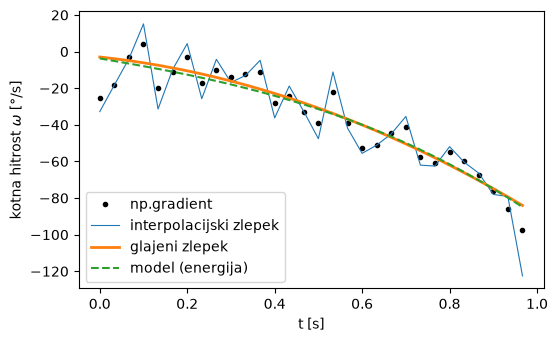

In [38]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(t_mer, np.degrees(omega_grad), "k.", label="np.gradient")
ax.plot(t_mer, np.degrees(omega_int), lw=0.8, label="interpolacijski zlepek")
ax.plot(t_mer, np.degrees(omega_gl), lw=2, label="glajeni zlepek")
ax.plot(t_mer, np.degrees(omega_model), "--", label="model (energija)")
ax.set_xlabel("t [s]")
ax.set_ylabel("kotna hitrost $\\omega$ [°/s]")
ax.legend()
plt.show()

Prikaz kotnega pospeška.

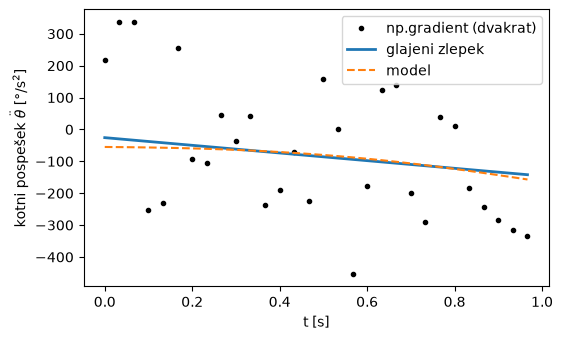

In [39]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(t_mer, np.degrees(alfa_grad), "k.", label="np.gradient (dvakrat)")
ax.plot(t_mer, np.degrees(alfa_gl), lw=2, label="glajeni zlepek")
ax.plot(t_mer, np.degrees(alfa_model), "--", label="model")
ax.set_xlabel("t [s]")
ax.set_ylabel("kotni pospešek $\\ddot\\theta$ [°/s$^2$]")
ax.legend()
plt.show()

**Interpretacija.** Raztros `np.gradient` okoli modela (8°/s) je reda pričakovanega ojačanega šuma, odvod interpolacijskega zlepka je s 14°/s še slabši, odvod glajenega zlepka (0,9°/s) pa sledi modelu, ki se ob odlepitvi približa 85°/s. Pri drugem odvodu dvakratno numerično odvajanje da raztros okoli 190°/s$^2$, več kot sam signal (od $-55$ do $-157$°/s$^2$), interpolacijski zlepek še bistveno več, glajeni zlepek pa pospešek zajame z raztrosom okoli 10°/s$^2$ (največ okoli 30°/s$^2$ na robovih). Sklep: iz videa lahko zanesljivo določimo kotno hitrost, pospešek pa le približno, in to zato, ker je glajeni zlepek pri izbranem $s$ en kubični polinom, ki dejanski potek dobro opiše; rezultat je zato močno odvisen od $s$. Za gladke podatke (npr. numerično rešitev enačbe gibanja) bi bil `np.gradient` povsem ustrezen.

---

# Reševanje diferencialnih enačb

## Padec lestve brez trenja

Enačbo gibanja pretvorimo v sistem prvega reda za stanje $[\theta, \omega]$,

$$ \dot\theta = \omega, \qquad \dot\omega = -\frac{3g}{2L}\cos\theta, \qquad \theta(0) = \theta_0,\ \omega(0) = 0, $$

(`le.desna_stran_de`) in ga rešimo s `scipy.integrate.solve_ivp`. Odlepitev od stene zajamemo z **dogodkom** (`events`): `le.sila_stene` vrne $N_B$ iz trenutnega stanja in reševanje se ustavi, ko $N_B$ pade skozi nič.

**Izbira metode.** Problem je gladek, kratek in **ni tog**, zato je eksplicitna metoda RK45 (Runge-Kutta 4(5) s prilagodljivim korakom) naravna izbira; implicitne metode (`BDF`, `Radau`) bi bile smiselne le pri togem sistemu. Tolerance nastavimo strožje od privzetih (`rtol=1e-8`), da primerjava z energijo in z Eulerjevo metodo ni omejena z napako reševalnika. Rešitev preverimo po treh neodvisnih poteh: kotna hitrost z energijo, čas dogodka z integralom, kot dogodka z ničlo $N_B$.

In [40]:
def odlepitev(t, y, L, g):
    """Sila stene iz stanja [theta, omega]; dogodek pri prehodu skozi nič."""
    return le.sila_stene(y[0], y[1], m, L, g)


odlepitev.terminal = True      # reševanje se ob dogodku ustavi
odlepitev.direction = -1       # le prehod iz pozitivne v negativno N_B

Reševanje z RK45 do dogodka odlepitve.

In [41]:
resitev_de = solve_ivp(le.desna_stran_de, (0.0, 3.0), [theta0, 0.0],
                       args=(L, g), method="RK45", rtol=1e-8, atol=1e-10,
                       events=odlepitev, dense_output=True)
t_od_de = resitev_de.t_events[0][0]
theta_od_de, omega_od_de = resitev_de.y_events[0][0]

Izpis rezultatov.

In [42]:
print(f"št. korakov: {resitev_de.t.size - 1}, klicev: {resitev_de.nfev}")
print(f"dogodek: t_od = {t_od_de:.6f} s, "
      f"theta_od = {np.degrees(theta_od_de):.4f}°")
print(f"omega ob odlepitvi = {np.degrees(omega_od_de):.1f} °/s")

št. korakov: 22, klicev: 134
dogodek: t_od = 0.988220 s, theta_od = 40.0870°
omega ob odlepitvi = -88.2 °/s


Preverjanje z energijo, integralom in ničlo $N_B$.

In [43]:
t_gosto = np.linspace(0.0, t_od_de, 200)
theta_de, omega_de = resitev_de.sol(t_gosto)
omega_energ = le.omega_energija(theta_de, theta0, L, g)
razlika_omega = np.abs(-omega_de - omega_energ).max()
print(f"največja razlika omega (solve_ivp - energija): "
      f"{razlika_omega:.1e} rad/s")
print(f"t_od: dogodek - quad = {t_od_de - t_od_quad:.1e} s")
print(f"theta_od: dogodek - brentq = "
      f"{np.degrees(theta_od_de - theta_od_brent):.1e}°")

največja razlika omega (solve_ivp - energija): 6.0e-09 rad/s
t_od: dogodek - quad = -1.7e-09 s
theta_od: dogodek - brentq = 1.4e-08°


Prikaz poteka kota in meritev iz videa.

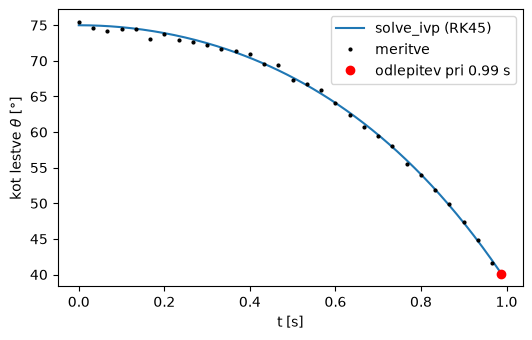

In [44]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(t_gosto, np.degrees(theta_de), label="solve_ivp (RK45)")
ax.plot(t_mer, np.degrees(theta_mer), "k.", ms=4, label="meritve")
ax.plot(t_od_de, np.degrees(theta_od_de), "ro",
        label=f"odlepitev pri {t_od_de:.2f} s")
ax.set_xlabel("t [s]")
ax.set_ylabel("kot lestve $\\theta$ [°]")
ax.legend()
plt.show()

**Interpretacija.** Lestev se odlepi po 0,988 s pri 40,1° s kotno hitrostjo 88°/s. Kotna hitrost iz `solve_ivp` se od tiste iz energije razlikuje za manj kot $10^{-8}$ rad/s, čas dogodka se z integralom ujema na $10^{-9}$ s, kot dogodka z ničlo na $10^{-8}$°; vsa tri preverjanja so neodvisna. Meritve iz videa ležijo na rešitvi v okviru šuma (največje odstopanje okoli 1°), kar pri sintetičnih meritvah potrjuje doslednost, ne modela. Fizikalno smiseln je počasen začetek: v prvi polovici sekunde se kot spremeni le za nekaj stopinj.

## Lastna Eulerjeva metoda in vpliv koraka

Za primerjavo smo v modul zapisali eksplicitno Eulerjevo metodo (`le.euler`), najenostavnejšo metodo prvega reda. Primerjamo kot pri $t = 0{,}9$ s (tik pred odlepitvijo) za korake od 0,05 s do 0,001 s; referenca je rešitev `solve_ivp`. Pričakujemo, da globalna napaka pada linearno s korakom; red metode ocenimo iz naklona v logaritemskem merilu.

In [45]:
t_primerjave = 0.9
theta_ref = resitev_de.sol(t_primerjave)[0]
koraki = np.array([0.05, 0.02, 0.01, 0.005, 0.002, 0.001])
napake_euler = np.zeros(koraki.size)
for i, korak in enumerate(koraki):
    t_euler = np.arange(0.0, t_primerjave + korak / 2, korak)
    y_euler = le.euler(le.desna_stran_de, [theta0, 0.0], t_euler, (L, g))
    napake_euler[i] = abs(y_euler[-1, 0] - theta_ref)
red_euler = np.polyfit(np.log(koraki), np.log(napake_euler), 1)[0]

Izpis napak in ocenjenega reda metode.

In [46]:
for korak, napaka in zip(koraki, napake_euler):
    print(f"korak {korak:.3f} s: napaka {np.degrees(napaka):.3f}°")
print(f"ocenjeni red metode (naklon v log-log): {red_euler:.2f}")

korak 0.050 s: napaka 3.053°
korak 0.020 s: napaka 1.284°
korak 0.010 s: napaka 0.654°
korak 0.005 s: napaka 0.330°
korak 0.002 s: napaka 0.133°
korak 0.001 s: napaka 0.066°
ocenjeni red metode (naklon v log-log): 0.98


**Interpretacija.** Napaka pada linearno s korakom (ocenjeni red 0,98), a je še pri koraku 1 ms (900 korakov) 0,07°, medtem ko `solve_ivp` z RK45 doseže napako pod $10^{-6}$° z nekaj deset koraki, ker prilagaja korak in ima višji red. Za izračun zato uporabljamo `solve_ivp`; Eulerjeva metoda je le referenca za razumevanje reda.

## Razširitev: trenje na tleh

Če lestev drsi po tleh s koeficientom trenja $\mu$, sila $F_A = \mu N_A$ nasprotuje gibanju spodnjega konca, reakcijski sili pa nista več določeni z energijo. Zapišemo Newton-Eulerjeve enačbe togega telesa (dve za težišče in momentno okoli težišča; kot zasuka telesa je $\pi - \theta$, zato $-I_G\ddot\theta = \sum M_G$), ki so **linearne** v $\ddot\theta$, $N_A$ in $N_B$, in jih rešimo s `sympy.solve`. Pri $\mu = 0$ se mora izraz ujemati z enačbo gibanja iz prvega poglavja. Model velja le, če lestev sploh zdrsne, tj. če je

$$ \mu < \frac{1}{2\tan\theta_0} \approx 0{,}13. $$

In [47]:
alfa = sym.symbols("alpha", real=True)
pospesek_x = -L_s / 2 * (sym.cos(theta) * omega**2 + sym.sin(theta) * alfa)
pospesek_y = L_s / 2 * (-sym.sin(theta) * omega**2 + sym.cos(theta) * alfa)
moment_G = L_s / 2 * (N_A * sym.cos(theta) - mu_s * N_A * sym.sin(theta)
                      - N_B * sym.sin(theta))
enacbe_ne = [sym.Eq(m_s * pospesek_x, N_B - mu_s * N_A),
             sym.Eq(m_s * pospesek_y, N_A - m_s * g_s),
             sym.Eq(-vztrajnostni_moment * alfa, moment_G)]
resitev_ne = sym.solve(enacbe_ne, [alfa, N_A, N_B])

Kotni pospešek s trenjem in numerični funkciji za reševanje.

In [48]:
display(sym.Eq(alfa, sym.simplify(resitev_ne[alfa])))
print("pri mu = 0:", sym.simplify(resitev_ne[alfa].subs(mu_s, 0)))
alfa_trenje = sym.lambdify((theta, omega, mu_s, L_s, g_s), resitev_ne[alfa])
N_B_trenje = sym.lambdify((theta, omega, mu_s, m_s, L_s, g_s),
                          resitev_ne[N_B])

Eq(alpha, 6*(-L*mu*omega**2*sin(theta)**2 + 2*g*mu*sin(theta) - g*cos(theta))/(L*(-3*mu*sin(2*theta) + 4)))

pri mu = 0: -3*g*cos(theta)/(2*L)


Desna stran in dogodek za padec s trenjem $\mu = 0{,}1$.

In [49]:
mu_tla = 0.1


def desna_stran_trenje(t, y, mu_tla):
    """Sistem 1. reda za padec z drsenjem po tleh s trenjem."""
    return [y[1], alfa_trenje(y[0], y[1], mu_tla, L, g)]


def odlepitev_trenje(t, y, mu_tla):
    """Sila stene pri padcu s trenjem; dogodek pri N_B = 0."""
    return N_B_trenje(y[0], y[1], mu_tla, m, L, g)


odlepitev_trenje.terminal = True
odlepitev_trenje.direction = -1

Reševanje do odlepitve.

In [50]:
resitev_trenje = solve_ivp(desna_stran_trenje, (0.0, 5.0), [theta0, 0.0],
                           args=(mu_tla,), rtol=1e-8, atol=1e-10,
                           events=odlepitev_trenje, dense_output=True)
t_od_trenje = resitev_trenje.t_events[0][0]
theta_od_trenje = resitev_trenje.y_events[0][0, 0]
print(f"mu = {mu_tla}: t_od = {t_od_trenje:.3f} s, "
      f"theta_od = {np.degrees(theta_od_trenje):.1f}°")

mu = 0.1: t_od = 1.577 s, theta_od = 35.8°


Primerjava padca brez trenja in s trenjem.

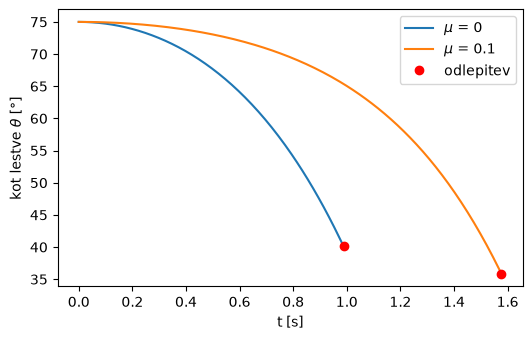

In [51]:
t_gosto_trenje = np.linspace(0.0, t_od_trenje, 200)
theta_trenje = resitev_trenje.sol(t_gosto_trenje)[0]
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(t_gosto, np.degrees(theta_de), label="$\\mu$ = 0")
ax.plot(t_gosto_trenje, np.degrees(theta_trenje), label=f"$\\mu$ = {mu_tla}")
ax.plot([t_od_de, t_od_trenje],
        np.degrees([theta_od_de, theta_od_trenje]), "ro", label="odlepitev")
ax.set_xlabel("t [s]")
ax.set_ylabel("kot lestve $\\theta$ [°]")
ax.legend()
plt.show()

**Interpretacija.** Pri $\mu = 0$ simbolna rešitev reproducira $\ddot\theta = -\frac{3g}{2L}\cos\theta$, kar potrjuje predznake v momentni enačbi. Trenje $\mu = 0{,}1$ padec upočasni (1,58 s namesto 0,99 s do odlepitve) in odlepitev premakne na manjši kot (35,8° namesto 40,1°), ker trenje odvzame del energije. Ali lestev sploh zdrsne, mora povedati statika; sama diferencialna enačba tega ne zazna.

## Animacija padca

Padec brez trenja do odlepitve prikažemo z `matplotlib.animation.FuncAnimation`; animacija je vdelana v HTML brez dodatnih paketov.

In [52]:
t_slike = np.linspace(0.0, t_od_de, 30)
koti_slik = resitev_de.sol(t_slike)[0]
fig, ax = plt.subplots(figsize=(3.4, 3.1), dpi=72)
ax.set_aspect("equal")
ax.plot([0, 0], [0, L], "k", lw=2)
ax.plot([0, L], [0, 0], "k", lw=2)
lestev_crta, = ax.plot([], [], color="tab:brown", lw=4)
napis = ax.text(2.0, 3.5, "")
ax.set_xlim(-0.2, L + 0.2)
ax.set_ylim(-0.2, L + 0.2)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
fig.tight_layout()


def osvezi(i):
    lestev_crta.set_data([L * np.cos(koti_slik[i]), 0.0],
                         [0.0, L * np.sin(koti_slik[i])])
    napis.set_text(f"t = {t_slike[i]:.2f} s")
    return lestev_crta, napis


animacija = FuncAnimation(fig, osvezi, frames=t_slike.size, interval=60,
                          blit=True)
plt.close(fig)
HTML(animacija.to_jshtml())

---

# Zaključek

Povzetek ključnih rezultatov.

In [53]:
povzetek = pd.DataFrame({
    "količina": ["koeficient trenja (curve_fit)",
                 "kritična lega osebe pri 60° (brentq)",
                 "kot, pri katerem je varna cela lestev",
                 "kritični kot brez osebe (brentq)",
                 "kot odlepitve pri padcu iz 75°",
                 "čas do odlepitve (quad / solve_ivp)",
                 "kotna hitrost ob odlepitvi",
                 "čas do odlepitve pri mu = 0,1"],
    "vrednost": [f"{mu:.3f} ± {sigma_mu:.3f}",
                 f"{x_kr_brent:.2f} m",
                 f"{np.degrees(kot_cele_lestve):.1f}°",
                 f"{np.degrees(theta_kr_brent):.1f}°",
                 f"{np.degrees(theta_od_de):.1f}°",
                 f"{t_od_quad:.3f} s / {t_od_de:.3f} s",
                 f"{np.degrees(abs(omega_od_de)):.0f} °/s",
                 f"{t_od_trenje:.2f} s"],
})
povzetek

,količina,vrednost
0,koeficient trenja (curve_fit),0.323 ± 0.002
1,kritična lega osebe pri 60° (brentq),2.27 m
2,"kot, pri katerem je varna cela lestev",70.9°
3,kritični kot brez osebe (brentq),57.1°
4,kot odlepitve pri padcu iz 75°,40.1°
5,čas do odlepitve (quad / solve_ivp),0.988 s / 0.988 s
6,kotna hitrost ob odlepitvi,88 °/s
7,"čas do odlepitve pri mu = 0,1",1.58 s


**Ključni rezultati.** Pri izmerjenem $\mu = 0{,}323$ lahko oseba (80 kg) po lestvi pod kotom 60° varno spleza le do **2,27 m** od 4 m; cela lestev je varna šele pri kotu nad **71°**, brez osebe pa lestev zdrsne pod **57°**, kar je skladno s pravilom 4 : 1 (75°) [3]. Na gladkih tleh lestev, izpuščena pri 75°, po **0,99 s** doseže **40°**, kjer se odlepi od stene s kotno hitrostjo 88°/s; trenje $\mu = 0{,}1$ padec upočasni na 1,6 s. Rezultati so fizikalno smiselni: reakcije rastejo linearno z lego osebe, kot odlepitve je neodvisen od mase in dolžine, padec iz strme lege začne počasi.

**Preverjanja.** Vsaka metoda je preverjena po neodvisni poti tam, kjer je uporabljena: simbolni izrazi s funkcijami modula in LU razcep z `np.linalg.solve` ter simbolno rešitvijo (`np.testing`), `brentq` in Newtonova metoda z analitičnimi izrazi, `quad` in ničla $N_B$ z dogodkom v `solve_ivp`, `solve_ivp` z ohranitvijo energije, Eulerjeva metoda s `solve_ivp`, model s trenjem pri $\mu = 0$ z modelom brez trenja. Formalnih enotskih testov modula nismo pisali.

**Omejitve.**
* Meritve so sintetične; ujemanje z modelom dokazuje doslednost postopka, ne pravilnosti modela.
* Negotovost $\mu$ ($\pm 0{,}002$) ni prenesena na $x_{kr}$ in $\theta_{kr}$, čeprav bi bila ocena zaradi linearnosti enostavna.
* Iz videa s 30 sličicami na sekundo lahko zanesljivo določimo kotno hitrost, pospešek le približno; parameter glajenja $s$ je določen iz ocene šuma, njegov vpliv na odvode ni preverjen.
* Model padca velja le do odlepitve; nadaljnje gibanje in udarec ob tla bi zahtevala dodatne prostostne stopnje in model trka.

**Možne izboljšave.** Realne meritve z dejansko lestvijo in hitrejšo kamero; prenos negotovosti $\mu$ na kritično lego; primerjava reševalnikov (`DOP853`, `Radau`) in toleranc; model gibanja po odlepitvi. Dodatna "ekstra" vsebina.

---

# Viri

1. G. Čepon, M. Pogačar, M. Kodrič: *Statika in kinematika*, UL Fakulteta za strojništvo, Ljubljana, 2023 (ravnotežje togega telesa, trenje).
2. J. Slavič: *Dinamika, mehanska nihanja in mehanika tekočin*, 2. izdaja, Fakulteta za strojništvo, Ljubljana, 2017 (poglavje 2.4: Kinetika togih teles, razdelek 2.4.2: Ravninsko gibanje togega telesa).
3. Health and Safety Executive (UK): *Safe use of ladders and stepladders: A brief guide*, INDG455, 2014 (naklon lestve 75°, pravilo 1 : 4).
4. J. Slavič: *Programiranje in numerične metode v ekosistemu Pythona*, Fakulteta za strojništvo, Univerza v Ljubljani (predavanja predmeta Numerične metode).
5. Dokumentacija SciPy: `scipy.linalg`, `scipy.interpolate`, `scipy.optimize`, `scipy.integrate`, https://docs.scipy.org/doc/scipy/.